# CMAPSS FD001: Feature Engineering

This notebook turns the raw readings from `01_eda.ipynb` into the feature matrix XGBoost trains on. Every transform lives in `src/features.py` as a reusable function. The API (`api/predictor.py`) calls the same logic at inference, so training and serving see the same features.

Two decisions from EDA are encoded here:

1. **Drop 7 near-constant sensors.** `drop_constant_sensors()` removes the channels with near-zero variance on FD001. Keeping them would add 14 extra rolling columns with no signal.

2. **Add a 30-cycle rolling mean and standard deviation per sensor, per engine.** `add_rolling_features()` records the trend in each channel, not the instantaneous reading. The trajectories in `01_eda.ipynb` showed cycle-to-cycle noise with a clearer direction over about 30 cycles.

The resulting matrix has **42 feature columns**: 14 active sensors, each as the raw value, the 30-cycle rolling mean, and the 30-cycle rolling standard deviation. I check that matrix on both train and test below.

**Environment:** `conda activate cmapss-rul` from the project root.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RAW = ROOT / "data" / "raw"
sys.path.insert(0, str(ROOT))

from src.features import (
    load_raw, add_rul, drop_constant_sensors,
    add_rolling_features, build_features,
    COLUMNS, CONSTANT_SENSORS, RUL_CLIP, ROLLING_WINDOW,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

print(f"ROOT: {ROOT}")
print(f"Active sensors after dropping constants: "
      f"{len(COLUMNS) - 5 - len(CONSTANT_SENSORS)}")  # 26 cols - 2 meta - 3 op - 7 constant

ROOT: /sessions/gracious-nifty-hamilton/mnt/cmapss_rul
Active sensors after dropping constants: 14


## 1. Load Raw Data and Apply the Full Pipeline

`build_features()` is the one-call wrapper: drop constant sensors, then add rolling mean and std for each remaining sensor. I apply it to training first so I can inspect columns and distributions before touching the test set.

In [2]:
train_raw    = load_raw(RAW / "train_FD001.txt")
train_labeled = add_rul(train_raw.copy())
train_fe     = build_features(train_labeled)

print(f"Raw shape:              {train_raw.shape}")
print(f"After feature eng:      {train_fe.shape}")
print(f"New columns added:      {train_fe.shape[1] - train_raw.shape[1]}")
print()
print("First 5 column names:")
print(train_fe.columns[:5].tolist())
print("\nLast 5 column names:")
print(train_fe.columns[-5:].tolist())

Raw shape:              (20631, 26)
After feature eng:      (20631, 48)
New columns added:      22

First 5 column names:
['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3']

Last 5 column names:
['sensor_14_std30', 'sensor_15_std30', 'sensor_17_std30', 'sensor_20_std30', 'sensor_21_std30']


## 2. Verify the Feature Matrix

The frame above should have 48 columns in total: the remaining original fields (including `rul`) plus 14 sensors times 2 rolling statistics. Of those 48, the model uses 42 features: everything except `unit`, `cycle`, `rul`, and the three operating-setting columns, which are constant on FD001.

I scan the column list for three things:
- No `CONSTANT_SENSORS` among the feature columns
- Every active sensor has both a `_mean30` and a `_std30` variant
- `unit`, `cycle`, and `rul` are still present (they are excluded by `get_feature_cols()`, not dropped here)

In [3]:
from src.model import get_feature_cols

feature_cols = get_feature_cols(train_fe)
print(f"Total feature columns: {len(feature_cols)}")
print()

# Confirm no constant sensor leaks through
leaked = [c for c in feature_cols if any(s in c for s in CONSTANT_SENSORS)]
print(f"Constant sensor leakage: {leaked if leaked else 'None ✓'}")

# Show raw vs rolling for one sensor
raw_only   = [c for c in feature_cols if not c.endswith(f"_mean{ROLLING_WINDOW}") and not c.endswith(f"_std{ROLLING_WINDOW}")]
mean_cols  = [c for c in feature_cols if c.endswith(f"_mean{ROLLING_WINDOW}")]
std_cols   = [c for c in feature_cols if c.endswith(f"_std{ROLLING_WINDOW}")]
print(f"Raw sensor columns retained:  {len(raw_only)}")
print(f"Rolling mean columns:         {len(mean_cols)}")
print(f"Rolling std columns:          {len(std_cols)}")

Total feature columns: 42

Constant sensor leakage: ['sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_11_mean30', 'sensor_12_mean30', 'sensor_13_mean30', 'sensor_14_mean30', 'sensor_15_mean30', 'sensor_17_mean30', 'sensor_11_std30', 'sensor_12_std30', 'sensor_13_std30', 'sensor_14_std30', 'sensor_15_std30', 'sensor_17_std30']
Raw sensor columns retained:  14
Rolling mean columns:         14
Rolling std columns:          14


## 3. Raw vs. Rolling Mean: What the Model Actually Sees

The plot below overlays raw `sensor_3` (HPC outlet temperature, later the top SHAP feature) against its 30-cycle rolling mean for one engine. This is the picture of what the model receives compared with a raw point reading.

The raw signal zigzags cycle to cycle. The rolling mean smooths that noise and shows the upward drift associated with compressor degradation. Without it, the model would have to infer trend from noisy points. Rolling standard deviation adds a second view: as engines degrade, some channels get noisier, so a rising `_std30` can flag change even when the mean is ambiguous. That is an association I will test with SHAP, not a physical proof by itself.

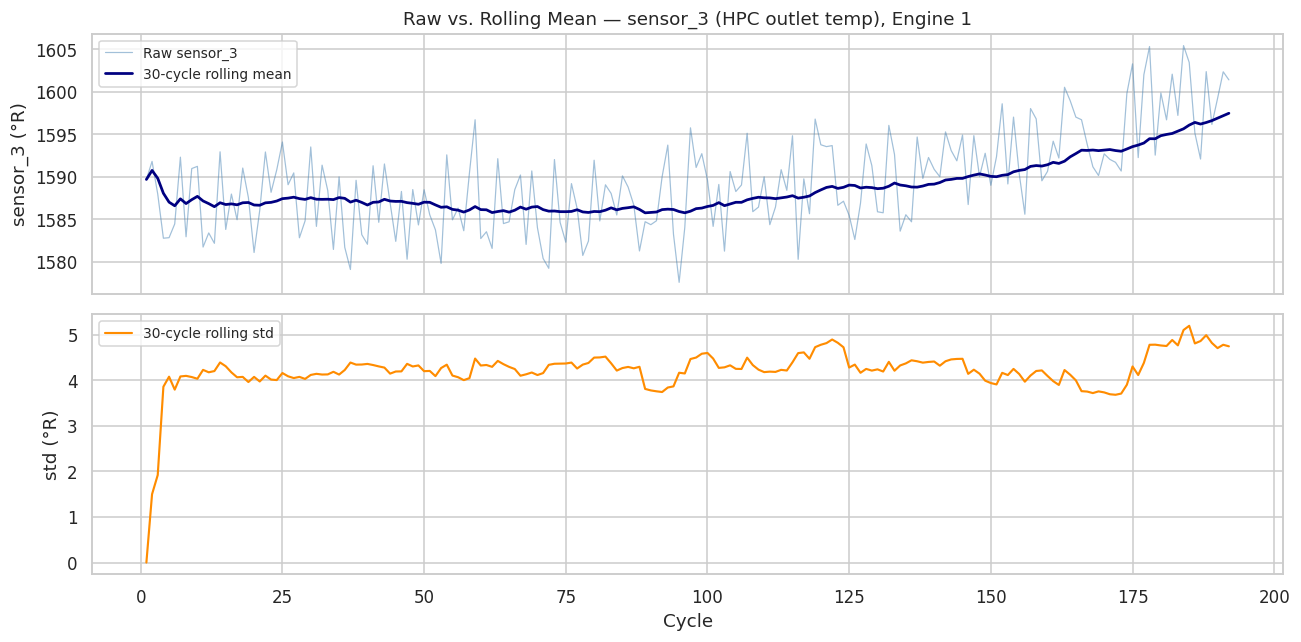

In [4]:
engine_id = 1   # single engine for clarity
eng = train_fe[train_fe["unit"] == engine_id].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(eng["cycle"], eng["sensor_3"], alpha=0.5, linewidth=0.8, label="Raw sensor_3", color="steelblue")
ax1.plot(eng["cycle"], eng["sensor_3_mean30"], linewidth=1.8, label="30-cycle rolling mean", color="navy")
ax1.set_ylabel("sensor_3 (°R)")
ax1.set_title(f"Raw vs. Rolling Mean - sensor_3 (HPC outlet temp), Engine {engine_id}")
ax1.legend(fontsize=9)

ax2.plot(eng["cycle"], eng["sensor_3_std30"], linewidth=1.4, color="darkorange", label="30-cycle rolling std")
ax2.set_ylabel("std (°R)")
ax2.set_xlabel("Cycle")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. Apply Feature Engineering to the Test Set

The CMAPSS test set is truncated: each engine stops before failure. True RUL at the last observed cycle is in `RUL_FD001.txt`. I apply the same `build_features()` pipeline, then keep the **last row per engine**. That row has the richest 30-cycle rolling context, and it is the row I predict from.

Feature names and count must match training exactly. A mismatch here is a silent train/serve skew.

In [5]:
test_raw = load_raw(RAW / "test_FD001.txt")
test_fe  = build_features(test_raw)

# Extract last cycle per engine - this is what the model predicts from
last_rows = test_fe.groupby("unit").last().reset_index()
X_test    = last_rows[feature_cols]

# True RUL labels, clipped at 125 (same convention as training)
rul_true = np.clip(np.loadtxt(RAW / "RUL_FD001.txt"), 0, 125)

print(f"Test engines:               {test_fe['unit'].nunique()}")
print(f"Test feature matrix shape:  {X_test.shape}")
print(f"Train feature cols == Test feature cols: {list(X_test.columns) == feature_cols}")
print(f"True RUL range: [{rul_true.min():.0f}, {rul_true.max():.0f}] cycles")

Test engines:               100
Test feature matrix shape:  (100, 42)
Train feature cols == Test feature cols: True
True RUL range: [7, 125] cycles


## 5. Test Set RUL Distribution

The histogram below is true RUL for the 100 test engines. Training is dominated by early-life rows labelled 125. Test labels span near-failure to the cap, so evaluation is not just "everything looks healthy."

RMSE on this set is what I report. A constant guess of the average test RUL would be a weak baseline. The baseline I actually train is Ridge on the same features (17.47 RMSE). Late errors (predicted RUL too high) delay maintenance. Early errors waste a slot but keep the engine safer. RMSE treats those two errors the same.

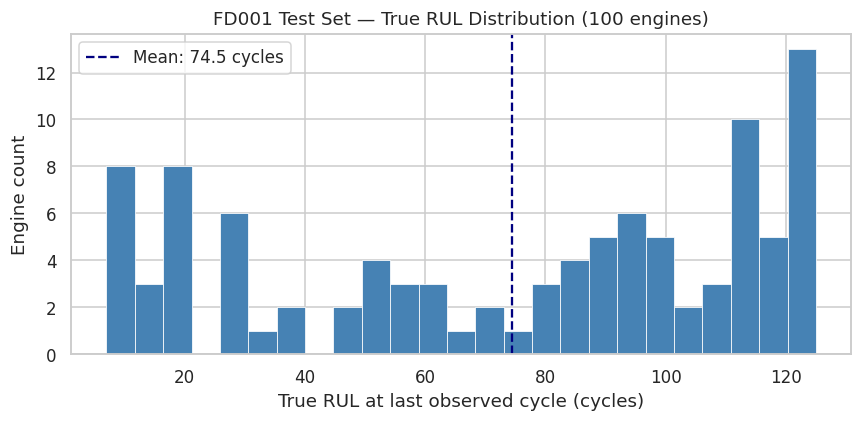

Mean test RUL:   74.5
Std  test RUL:   40.1
Naive mean RMSE: 40.1  (predicting the mean for every engine)


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rul_true, bins=25, color="steelblue", edgecolor="white", linewidth=0.5)
ax.axvline(rul_true.mean(), color="navy", linestyle="--", linewidth=1.5,
           label=f"Mean: {rul_true.mean():.1f} cycles")
ax.set_xlabel("True RUL at last observed cycle (cycles)")
ax.set_ylabel("Engine count")
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rul_true, bins=25, color="steelblue", edgecolor="white", linewidth=0.5)
ax.axvline(rul_true.mean(), color="navy", linestyle="--", linewidth=1.5,
           label=f"Mean: {rul_true.mean():.1f} cycles")
ax.set_xlabel("True RUL at last observed cycle (cycles)")
ax.set_ylabel("Engine count")
ax.set_title("FD001 test set: true RUL distribution (100 engines)")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Mean test RUL: {rul_true.mean():.1f}")
print(f"Std of test RUL labels: {rul_true.std():.1f}")
print("That std is the error of a constant-mean guess. The trained baseline is Ridge (17.47 RMSE).")

## What this notebook produced

Feature engineering is done. I now have:

- A **training feature matrix** with 42 columns across 20,631 rows from 100 engines.
- A **test feature matrix** with 42 columns, one row per engine (100 rows), aligned with the true RUL labels in `RUL_FD001.txt`.
- Checks: no constant-sensor leakage, no train/test column mismatch, rolling features computed only within each engine's sequence.

`03_modeling.ipynb` takes these into a grouped train/validation split, fits Ridge and XGBoost, evaluates both on the official test set, and uses SHAP to show which channels move each prediction. SHAP is attribution to this model, not a causal map of HPC fouling.